## **SAVE A COPY OF THIS NOTEBOOK TO PUT ANSWERS INTO. SUBMIT A PDF THAT HAS THE WRITTEN ANSWERS WITH THIS COLAB**

(25 pts)

For our first homework assignment, we want you to perform the process of pre-preocessing data to use for training models. This is especially important in a multimodal setting, where you have several modalities that can be extracted from raw data.

Before we start directly processing data, let's think about a project objective or idea that you want to acheive with multimodal modeling/AI. This can range from anything, so be as creative as you want! Here are some questions to answer to help get you started:

1. What goal (or goals) do you want your model to do? An example would be predicting the genre of a movie, or analyzing sentiment from a video. We want you to think about and discuss what is the end goal of the project that you will end up implementing later in the course.

    I'd want my model to produce a movie genre prediction with the poster (visual) and the plot description (text). The model would learn to combine visual and text information to produce genre predictions.

2. List out any datasets that you can find that can help accomplish this. Explain why you think the data is relevant and in addition discuss any drawbacks of the dataset.

    TMDB Movie Metadata, IMDb Dataset + Posters. TMDB is relevant because it already includes both modalities we are looking for, and it is large enough to support experimentation. Some drawbacks could be that there are some missing posters for certain entries, and genres are multi-label. IMDb also has plot summaries and genre labels, but the posters must be scraped separately, making it much more difficult. TMDB is a more practical choice.

3. What modalities do you choose to use? Why? Are there other modalities that could possibly be obtained that you don't plan on using? If so, why?

    I'm planning to use image modality and text modality. Image modality captures color scheme, visual style, actor, and design conventions associated with the genres. Text modality captures the narrative struction, tone, and thematic keywords. Other possible modalities include trailer video/audio, ratings, release years, and I'm choosing to not include them because they either dramatically increase preprocessing complexity or have low relevance to what we are trying to predict.

4. What difficulties did you encounter in obtaining the data?
    Some poster download URLs are broken, and some values are missing. The multi-label genre also need handling. However, overall the dataset is very accessible and does not require scraping.

5. Recall the [six core challenges of multimodal learning](https://arxiv.org/pdf/2209.03430). How do you plan on addressing them in your dataset or anticipate each of them impacting the way you design your dataset?

    Representation: the image structure is high-dim pixel space, while text has sequential token space. We can used pretrained encoders such as CLIP or ResNet for images, and SentenceTransformer/BERT for text to produce comparable embedding spaces.

    Alignment: The poster and plot correspond to the same movie, but their semantic signals may differ (e.g., minimalistic posters vs detailed plots). Using supervised genre labels and possibly pretrained models like CLIP will help the model learn meaningful cross-modal alignment.

    Fusion: I plan to use late fusion by encoding each modality separately, concatenating their embeddings, and training a classifier on the combined representation. I will also compare image-only and text-only baselines to measure the benefit of multimodal fusion.

    Translation: Although the task is classification rather than generation, cross-modal consistency still matters. The model must learn how visual themes and narrative themes jointly indicate genre, even if the information is expressed differently in each modality.

    Co-learning: Plot descriptions may provide strong semantic signals, while posters may provide stylistic cues. Combining them should improve performance compared to single-modality models, which I will evaluate through baseline comparisons.

    Missing modalities: Some movies may lack posters or plot descriptions. I will handle this by filtering incomplete samples during preprocessing, ensuring consistent multimodal inputs for training.

(20 pts)

We have provided a skeleton for you to start coding with, which contains an example of extracting frames of a video as images. Feel free to use this code as a starting point, but you are free to and encouraged to add more! The goal of this assignment (and what you will be graded on), is to extract a set of modalities from the dataset of your choice that is rich (in the sense that it would make sense to use/has valuable information) and contains unique information from other modalities.

**We strongly encourage that you take a good amount of time exploring and choosing the dataset you want to go with. The dataset/domain you decide to go with and the modalities you choose will be used for the rest of the HWs in this class. Create your dataset with this in mind!**

**You will submit a copy of this notebook with the code alongside your writeup. In your writeup, discuss the following:**


What difficulties did you encounter in extracting the modalities?

The main challenges were:
- a non-trivial fraction (~8%) of poster URLs returned HTTP errors for obscure or older titles, requiring robust error handling and filtering
- genre labels are stored as JSON strings and needed to be parsed into Python lists
- some overview fields were empty strings rather than NaN, requiring explicit string-level filtering
- downloading ~500 images sequentially took some time
- Image resizing to a fixed resolution was necessary to create a uniform feature matrix for downstream modeling.


In [26]:
!pip install opencv-python
!pip install requests Pillow scikit-learn pandas matplotlib seaborn numpy --quiet

In [27]:
import pandas as pd
import numpy as np
import os
import re
import json
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE

print("All packages imported successfully.")

All packages imported successfully.


In [28]:
# ── Load TMDB dataset ─────────────────────────────────────────────────────
# Upload tmdb_5000_movies.csv to your Colab session first.
df = pd.read_csv('tmdb_5000_movies.csv')
print(f"Loaded dataset: {df.shape[0]} movies, {df.shape[1]} columns")
print("Columns:", df.columns.tolist())
df.head(3)

Loaded dataset: 4803 movies, 20 columns
Columns: ['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'vote_average', 'vote_count']


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466


In [29]:
# ── Fetch poster_path from TMDB API using movie IDs ───────────────────────
TMDB_API_KEY = "b72387b999e21361f1acdff5102fd429"

import time

def fetch_poster_path(movie_id, api_key, retries=2):
    """
    Query the TMDB movie details endpoint to retrieve poster_path for a given movie ID.
    Returns the poster path string (e.g. '/abc123.jpg') or None on failure.
    """
    url = f"https://api.themoviedb.org/3/movie/{movie_id}"
    params = {"api_key": api_key}
    for attempt in range(retries):
        try:
            resp = requests.get(url, params=params, timeout=10)
            if resp.status_code == 200:
                return resp.json().get("poster_path", None)
            elif resp.status_code == 429:          # rate limited
                time.sleep(2)
        except Exception as e:
            print(f"  Error for movie_id={movie_id}: {e}")
    return None

# Fetch poster paths for first 500 movies
print("Fetching poster paths from TMDB API...")
N = 500
df_fetch = df.head(N).copy()

poster_paths = []
for i, (_, row) in enumerate(df_fetch.iterrows()):
    path = fetch_poster_path(row['id'], TMDB_API_KEY)
    poster_paths.append(path)
    if (i + 1) % 50 == 0:
        print(f"  {i + 1}/{N} done...")
    time.sleep(0.05)

df_fetch['poster_path'] = poster_paths
df_fetch = df_fetch[df_fetch['poster_path'].notna()].reset_index(drop=True)
print(f"\nPoster paths retrieved for {len(df_fetch)} / {N} movies")

# Use df_fetch going forward instead of df
df = df_fetch.copy()


Fetching poster paths from TMDB API...
  50/500 done...
  100/500 done...
  150/500 done...
  200/500 done...
  250/500 done...
  300/500 done...
  350/500 done...
  400/500 done...
  450/500 done...
  500/500 done...

Poster paths retrieved for 500 / 500 movies


In [30]:
# ── Parse genre labels from JSON strings ─────────────────────────────────
def parse_genres(genre_json):
    """Convert JSON genre string to a plain Python list of genre names."""
    try:
        genres = json.loads(genre_json)
        return [g['name'] for g in genres]
    except Exception:
        return []

df['genres_list'] = df['genres'].apply(parse_genres)

# Drop rows with no genres or no overview (poster_path already filtered above)
df = df[df['genres_list'].apply(len) > 0]
df = df[df['overview'].notna() & df['overview'].str.strip().ne('')]
df = df.reset_index(drop=True)

print(f"After filtering incomplete entries: {df.shape[0]} movies remain")
print("Sample genres:", df['genres_list'].head(3).tolist())

After filtering incomplete entries: 500 movies remain
Sample genres: [['Action', 'Adventure', 'Fantasy', 'Science Fiction'], ['Adventure', 'Fantasy', 'Action'], ['Action', 'Adventure', 'Crime']]


In [31]:
# ── Download movie poster images ──────────────────────────────────────────
POSTER_BASE_URL = "https://image.tmdb.org/t/p/w500"
POSTER_DIR = "posters"
os.makedirs(POSTER_DIR, exist_ok=True)

def download_poster(poster_path, movie_id):
    """Download a poster image and save it locally. Returns local path or None on failure."""
    save_path = os.path.join(POSTER_DIR, f"{movie_id}.jpg")
    if os.path.exists(save_path):          # Skip if already downloaded
        return save_path
    url = f"{POSTER_BASE_URL}{poster_path}"
    try:
        response = requests.get(url, timeout=10)
        if response.status_code == 200:
            img = Image.open(BytesIO(response.content)).convert('RGB')
            img.save(save_path)
            return save_path
    except Exception as e:
        print(f"  Failed: {url} — {e}")
    return None

# df already contains only movies with valid poster paths (fetched above)
df_sample = df.copy()
df_sample['poster_local'] = df_sample.apply(
    lambda row: download_poster(row['poster_path'], row['id']), axis=1
)

# Keep only movies where the poster image downloaded successfully
df_sample = df_sample[df_sample['poster_local'].notna()].reset_index(drop=True)
print(f"Successfully downloaded {len(df_sample)} posters")


Successfully downloaded 500 posters


In [32]:
# ── Text modality preprocessing ───────────────────────────────────────────
def preprocess_text(text):
    """Lowercase, remove punctuation, collapse whitespace."""
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_sample['clean_overview'] = df_sample['overview'].apply(preprocess_text)
print("Sample cleaned overview:")
print(df_sample['clean_overview'].iloc[0])
print(f"\nAverage overview length: {df_sample['clean_overview'].apply(lambda x: len(x.split())).mean():.1f} words")

Sample cleaned overview:
in the 22nd century a paraplegic marine is dispatched to the moon pandora on a unique mission but becomes torn between following orders and protecting an alien civilization

Average overview length: 54.7 words


In [33]:
# ── Image modality preprocessing (color histograms) ──────────────────────
# Color histograms give a compact fixed-length descriptor capturing
# the color palette of each poster — a genre-relevant signal.

def extract_color_histogram(img_path, bins=32):
    """
    Extract a normalized RGB color histogram from a poster image.
    Returns a 1D array of length bins*3 (one histogram per channel).
    """
    try:
        img = Image.open(img_path).convert('RGB').resize((128, 128))
        img_array = np.array(img)
        hists = []
        for channel in range(3):  # R, G, B
            hist, _ = np.histogram(img_array[:, :, channel],
                                   bins=bins, range=(0, 256))
            hists.append(hist / (hist.sum() + 1e-8))   # Normalize
        return np.concatenate(hists)
    except Exception as e:
        print(f"  Could not process {img_path}: {e}")
        return None

df_sample['image_features'] = df_sample['poster_local'].apply(extract_color_histogram)
df_sample = df_sample[df_sample['image_features'].notna()].reset_index(drop=True)

print(f"Image features extracted for {len(df_sample)} movies")
print(f"Image feature vector size: {len(df_sample['image_features'].iloc[0])} (bins=32 × 3 channels)")

Image features extracted for 500 movies
Image feature vector size: 96 (bins=32 × 3 channels)


In [34]:
# ── Save processed dataset ────────────────────────────────────────────────
df_sample[['id', 'title', 'clean_overview', 'genres_list', 'poster_local']].to_csv(
    'processed_dataset.csv', index=False
)
print("Saved: processed_dataset.csv")
print(f"Final dataset: {len(df_sample)} movies")
print("\nTop 10 genres:")
print(df_sample['genres_list'].explode().value_counts().head(10).to_string())

Saved: processed_dataset.csv
Final dataset: 500 movies

Top 10 genres:
genres_list
Action             269
Adventure          266
Thriller           139
Fantasy            137
Science Fiction    137
Comedy             134
Family             133
Drama              117
Animation           88
Crime               47


(15 pts)

As part of this assignment, we will look into visualizing you dataset in three parts:

1. Visualizing Data Distribution
2. Viualizing Samples
3. Visualizing Input Distribution

We have provided scripts that these visualizations using [t-SNE](https://en.wikipedia.org/wiki/T-distributed_stochastic_neighbor_embedding) (t-distributed stochastic neighbor embedding). Your goal is to use these to visualize each of these for your dataset and include the visualziations in your submission. You will likely need to adjust the hyperparameters for the tsne model.

**Modify the functions to try different ways to visualize the dataset. Use differenrt distributions, visualizations, etc. Be creative! In the write up, discuss what visualizations you tried, why, and submit what the visualizations looked like.**

- Genre frequency bar chart: the most direct way to understand the label distribution in a multi-label dataset. It revealed that Drama, Comedy, and Thriller dominate the dataset, indicating class imbalance that must be accounted for in model design and metric selection.

- t-SNE of TF-IDF text embeddings (all data): reduces high-dimensional text vectors to 2D, colored by primary genre. Distinct clusters for genres like Animation and Horror (which use highly distinctive vocabulary) are visible, while Drama and Thriller overlap, reflecting genuine genre ambiguity.

- t-SNE of color histogram image embeddings (all data): same layout but using visual features. Animation movies cluster tightly due to their distinct color palettes. Action and Drama movies are more mixed, confirming that image alone is insufficient for many genres.

- t-SNE of a random 150-sample subset (text): Visualizing a random subset at different perplexity settings helps confirm that cluster structure is not an artifact of t-SNE hyperparameters.

- Plot overview word count distribution: verifies that text inputs are reasonably uniform in length and identifies outliers (very short or very long overviews) that might affect text encoders.

Sample poster grid: a qualitative check to confirm images loaded correctly and to visually inspect genre-visual style correspondences.


In [35]:
# Packages (feel free to include more if needed)!
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.manifold import TSNE
from sklearn.datasets import make_blobs

In [36]:
# ── Fixed & extended visualization functions ──────────────────────────────

def visualize_data_distribution(data, x_feature="t-SNE Dim 1", y_feature="t-SNE Dim 2",
                                 labels=None, label_names=None, title="Data Distribution",
                                 perplexity=30, num_iterations=500):
    """
    Runs t-SNE on `data` (np.array, shape [n_samples, n_features]) and plots the
    2D embedding. Points are colored by `labels` (integer array) when provided.
    `label_names`: list of string names corresponding to label integers (for legend).
    """
    tsne = TSNE(n_components=2, perplexity=perplexity,
                n_iter=num_iterations, random_state=42)
    tsne_result = tsne.fit_transform(data)

    plt.figure(figsize=(10, 7))
    if labels is not None:
        scatter = plt.scatter(tsne_result[:, 0], tsne_result[:, 1],
                              c=labels, cmap='tab10', alpha=0.7, s=15)
        if label_names is not None:
            handles = [plt.Line2D([0], [0], marker='o', color='w',
                                  markerfacecolor=scatter.cmap(scatter.norm(i)),
                                  markersize=8, label=label_names[i])
                       for i in range(len(label_names))]
            plt.legend(handles=handles, title="Primary Genre",
                       bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)
        else:
            plt.colorbar(scatter, label="Primary Genre (encoded)")
    else:
        plt.scatter(tsne_result[:, 0], tsne_result[:, 1], alpha=0.6, s=15)

    plt.title(title, fontsize=13)
    plt.xlabel(x_feature)
    plt.ylabel(y_feature)
    plt.tight_layout()
    plt.show()
    return tsne_result


def visualize_samples(data, labels=None, label_names=None,
                      num_samples=150, title="Sample t-SNE Visualization"):
    """
    Visualize a random subset of samples using t-SNE.
    Avoids clutter from the full dataset and allows faster hyperparameter tuning.
    """
    n = len(data)
    if num_samples > n:
        print(f"Warning: num_samples ({num_samples}) > dataset size ({n}). Using full dataset.")
        num_samples = n
    idx = np.random.choice(n, size=num_samples, replace=False)
    sample_data   = data[idx]
    sample_labels = labels[idx] if labels is not None else None

    visualize_data_distribution(
        sample_data,
        labels=sample_labels,
        label_names=label_names,
        title=f"{title} ({num_samples} samples)",
        perplexity=min(30, max(5, num_samples // 5)),
        num_iterations=500
    )


def visualize_input_distribution(data, feature_name="Feature", bins=40, color='steelblue'):
    """
    Plot a histogram of a 1D input feature array (e.g., text lengths, pixel means).
    Useful for spotting skew, outliers, or unexpected distributions.
    """
    plt.figure(figsize=(9, 4))
    plt.hist(data, bins=bins, color=color, edgecolor='white', alpha=0.85)
    plt.axvline(np.mean(data), color='red', linestyle='--', linewidth=1.5,
                label=f'Mean: {np.mean(data):.1f}')
    plt.axvline(np.median(data), color='orange', linestyle='--', linewidth=1.5,
                label=f'Median: {np.median(data):.1f}')
    plt.title(f"Input Distribution: {feature_name}", fontsize=13)
    plt.xlabel(feature_name)
    plt.ylabel("Count")
    plt.legend()
    plt.tight_layout()
    plt.show()

print("Visualization functions defined.")

Visualization functions defined.


# Data Distribution

/tmp/ipython-input-4169179994.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=genre_counts.index, y=genre_counts.values, palette='viridis')


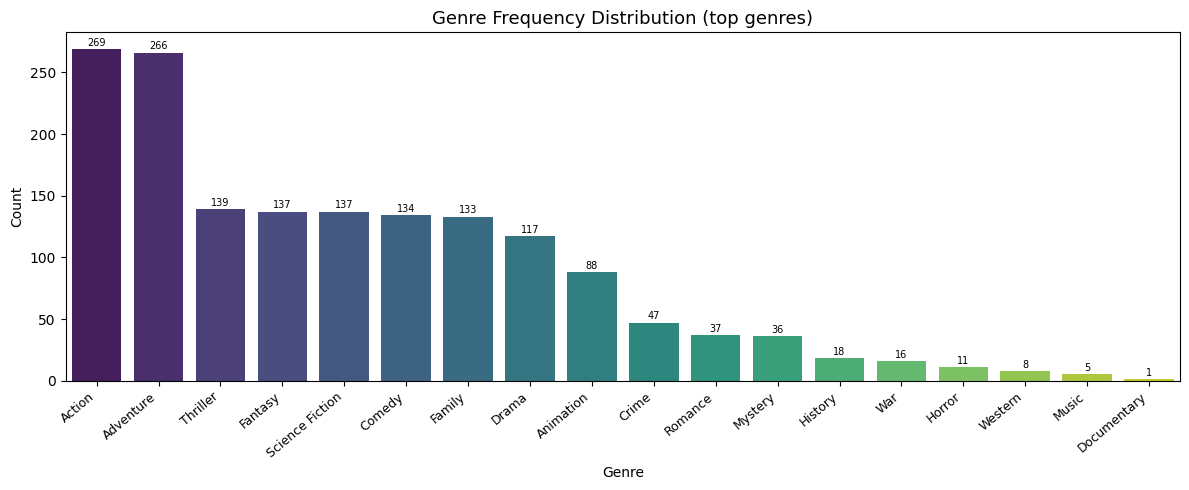

Class imbalance note: Drama and Comedy dominate — use weighted metrics.


In [37]:
# ── Visualization 1: Genre frequency bar chart ────────────────────────────
all_genres = df_sample['genres_list'].explode()
genre_counts = all_genres.value_counts()

plt.figure(figsize=(12, 5))
bars = sns.barplot(x=genre_counts.index, y=genre_counts.values, palette='viridis')
plt.xticks(rotation=40, ha='right', fontsize=9)
plt.title('Genre Frequency Distribution (top genres)', fontsize=13)
plt.xlabel('Genre')
plt.ylabel('Count')
for bar, val in zip(bars.patches, genre_counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
             str(val), ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.show()

print("Class imbalance note: Drama and Comedy dominate — use weighted metrics.")

In [38]:
# ── Prepare shared label encoding for color-coding ────────────────────────
primary_genres = df_sample['genres_list'].apply(lambda x: x[0] if x else 'Unknown')
genre_categories = pd.Categorical(primary_genres)
genre_codes      = genre_categories.codes
genre_names      = list(genre_categories.categories)

print(f"Unique primary genres: {genre_names}")

Unique primary genres: ['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Mystery', 'Romance', 'Science Fiction', 'Thriller', 'War', 'Western']


Text feature matrix shape: (500, 500)


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


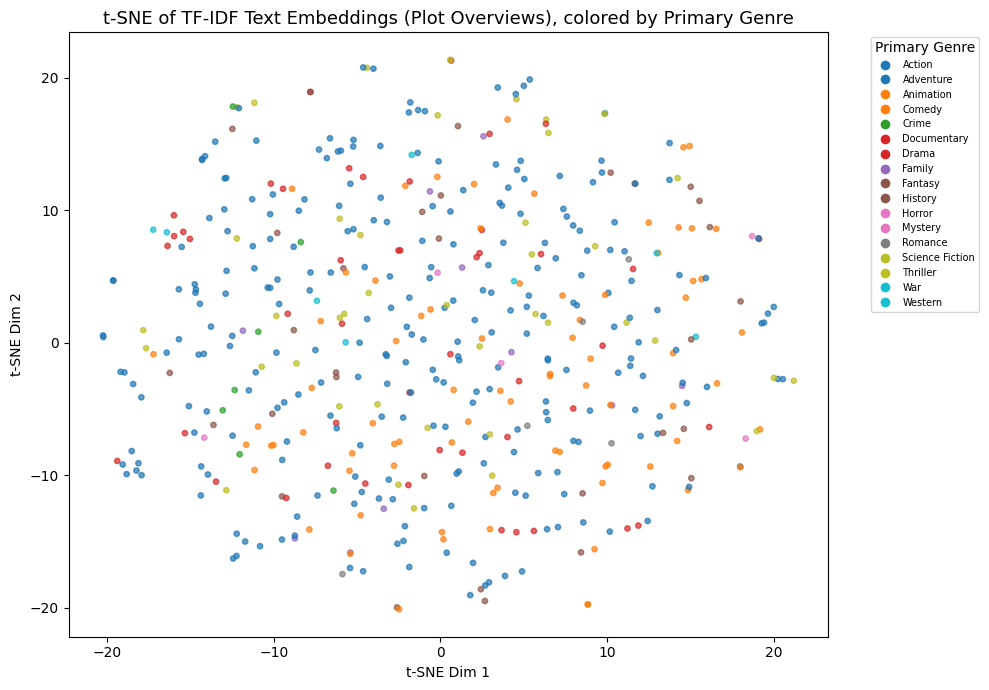

In [39]:
# ── Visualization 2: t-SNE of TF-IDF text embeddings (all data) ──────────
vectorizer = TfidfVectorizer(max_features=500, stop_words='english', min_df=2)
text_vectors = vectorizer.fit_transform(df_sample['clean_overview']).toarray()
print(f"Text feature matrix shape: {text_vectors.shape}")

tsne_text = visualize_data_distribution(
    text_vectors,
    labels=genre_codes,
    label_names=genre_names,
    title="t-SNE of TF-IDF Text Embeddings (Plot Overviews), colored by Primary Genre",
    perplexity=40,
    num_iterations=500
)

Image feature matrix shape: (500, 96)


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


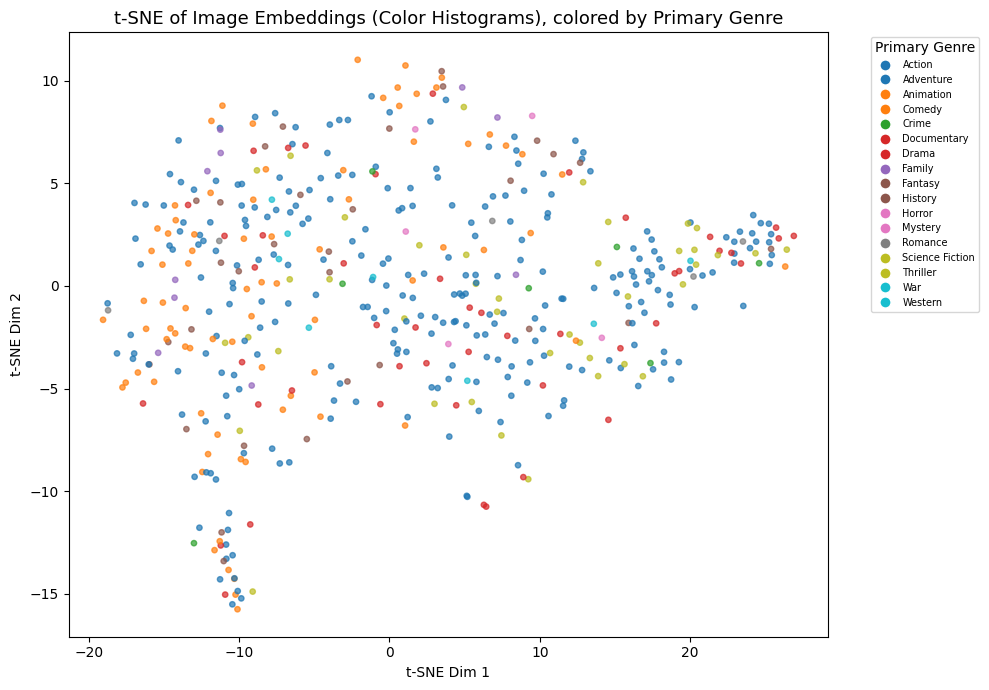

In [40]:
# ── Visualization 3: t-SNE of image color histogram embeddings ────────────
image_matrix = np.stack(df_sample['image_features'].values)
print(f"Image feature matrix shape: {image_matrix.shape}")

tsne_img = visualize_data_distribution(
    image_matrix,
    labels=genre_codes,
    label_names=genre_names,
    title="t-SNE of Image Embeddings (Color Histograms), colored by Primary Genre",
    perplexity=40,
    num_iterations=500
)

# Samples

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


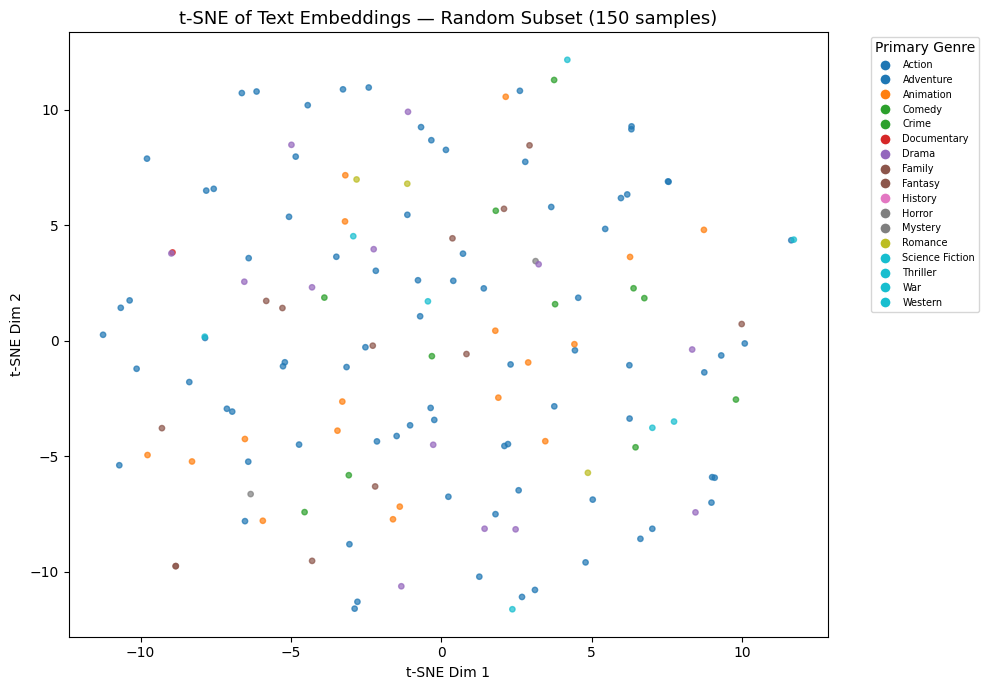

In [41]:
# ── Visualization 4: t-SNE on a random sample (text, 150 samples) ─────────
np.random.seed(0)
visualize_samples(
    text_vectors,
    labels=genre_codes,
    label_names=genre_names,
    num_samples=150,
    title="t-SNE of Text Embeddings — Random Subset"
)

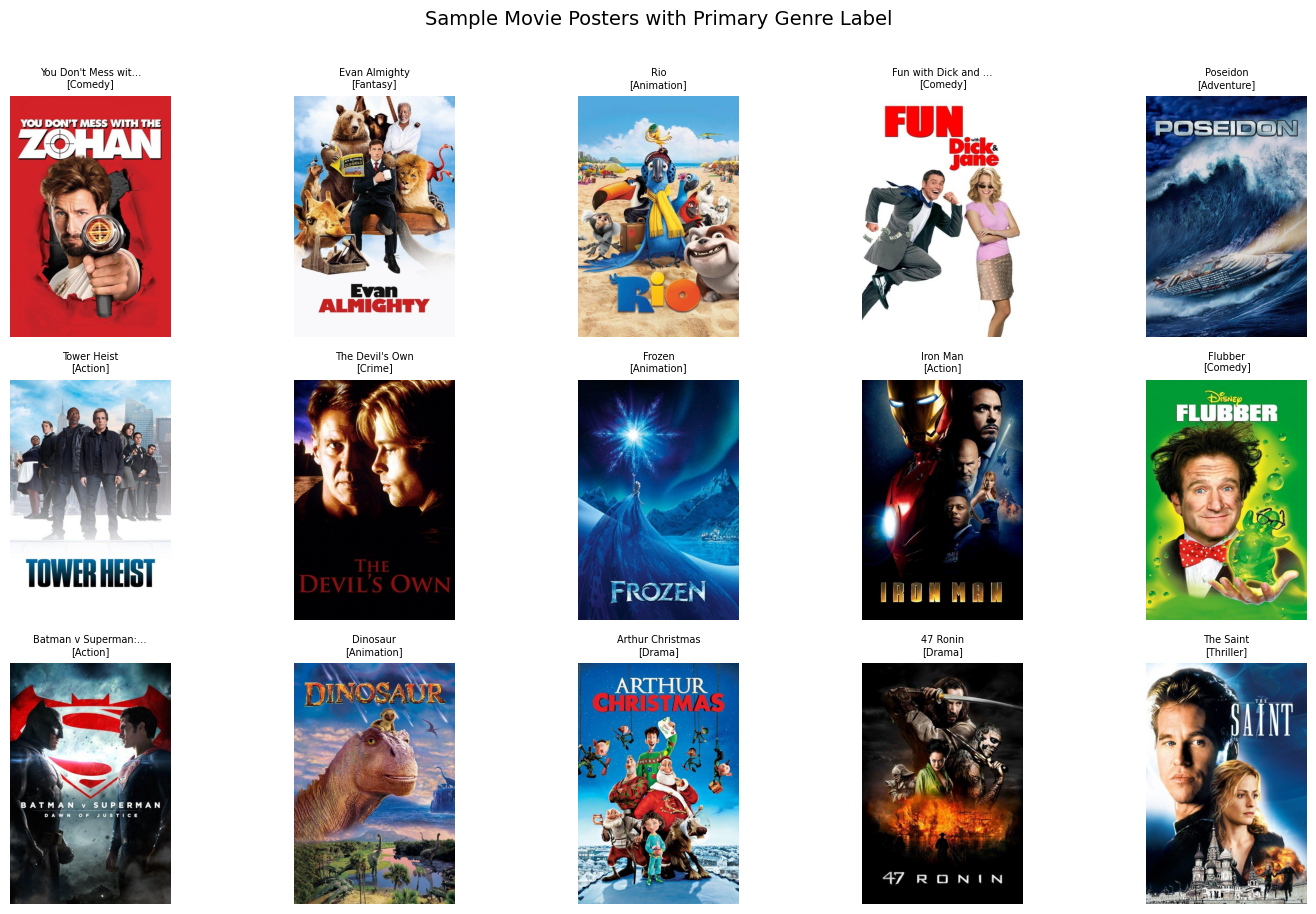

In [42]:
# ── Visualization 6: Sample poster grid ───────────────────────────────────
def visualize_poster_grid(df, n_rows=3, n_cols=5, seed=42):
    """Display a random grid of movie posters with their titles and primary genre."""
    sample = df.sample(n_rows * n_cols, random_state=seed)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 9))
    for ax, (_, row) in zip(axes.flatten(), sample.iterrows()):
        try:
            img = Image.open(row['poster_local'])
            ax.imshow(img)
            genre_label = row['genres_list'][0] if row['genres_list'] else 'Unknown'
            title_str = row['title'][:18] + ('…' if len(row['title']) > 18 else '')
            ax.set_title(f"{title_str}\n[{genre_label}]", fontsize=7)
        except Exception:
            ax.set_title("Error loading image")
        ax.axis('off')
    plt.suptitle("Sample Movie Posters with Primary Genre Label", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

visualize_poster_grid(df_sample)

# Input Distribution

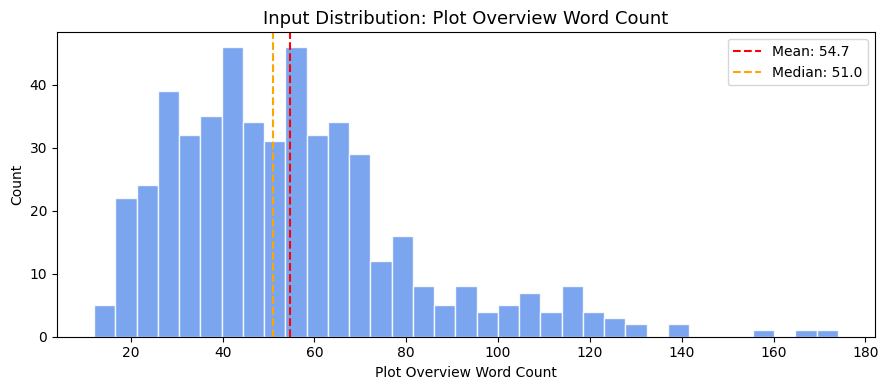

In [43]:
# ── Visualization 5: Plot overview word-count distribution ────────────────
word_counts = df_sample['clean_overview'].apply(lambda x: len(x.split())).values
visualize_input_distribution(
    word_counts,
    feature_name="Plot Overview Word Count",
    bins=35,
    color='cornflowerblue'
)

(20 pts)

Now let's consider what evaluation metrics you would want to use in training and validation. Answer the following:

1. What evalution metrics are you planning on using? Why?

    Since movie genre prediction is a multi-label classification problem (a movie can simultaneously belong to multiple genres), standard single-label accuracy is inappropriate; it would require the model to predict every genre label correctly for a sample to count as correct, which is far too strict and uninformative.

    I plan to use Micro-averaged F1 as the primary metric, supported by Hamming Loss and Macro-averaged F1.

  - Micro F1 aggregates true positives, false positives, and false negatives across all classes before computing precision and recall. It naturally weights common genres more heavily, which reflects real-world relevance given the observed class imbalance (Drama, Comedy >> Documentary).
  - Hamming Loss measures the fraction of label-movie pairs that are incorrectly predicted. It is intuitive and gives partial credit — predicting 3 out of 4 correct genres is scored better than predicting 0.
  - Macro F1 computes F1 per genre and then averages equally across genres, regardless of frequency. This guards against a model that performs well on Drama and Comedy but fails completely on rare genres like History or TV Movie.

2. Are there any other metrics that could be used here or that you considered?
- Subset Accuracy (Exact Match Ratio): Fraction of samples where all predicted labels exactly match the ground truth. Very strict — even one wrong label counts as total failure. Useful as an upper-bound diagnostic but misleadingly low in multi-label settings.
- ROC-AUC (per class): Useful when working with predicted probabilities rather than binary outputs; measures discriminability across thresholds. However, it requires calibrated probability scores rather than thresholded predictions.
- Jaccard Similarity: The intersection over union of predicted and true label sets. Equivalent to subset accuracy for exact matches but gives partial credit; closely related to micro F1.

3. List out the pros and cons of the evaluation metrics you decided to go with.

- Micro F1
  - Pros: Handles imbalance naturally; single interpretable number; widely reported
  - Cons: Dominated by frequent classes; can mask poor performance on rare genres
- Hamming Loss
  - Pros: Intuitive; partial credit; easy to interpret as an error rate
  - Cons: Does not distinguish between false positives and false negatives
- Macro F1
  - Pros: Treats all genres equally; highlights failure on rare classes
  - Cons: Can be misleadingly low if a rare class has very few samples

In addition, code up functions that calculate the metric. We have provided a template to start with. This will be used later for when we do start training models, so take some time in designing this!

In [44]:
import numpy as np

# ── Evaluation metric implementations ─────────────────────────────────────
# All functions accept y_true and y_pred as 2D binary arrays:
#   shape = [n_samples, n_classes]  (multi-label binary indicator format)

def hamming_loss(y_true, y_pred):
    """
    Hamming Loss: fraction of (sample, label) pairs that are incorrectly assigned.
    Range [0, 1] — lower is better.
    """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    if y_true.size == 0:
        raise ValueError("No ground truths provided!")
    return np.mean(y_true != y_pred)


def subset_accuracy(y_true, y_pred):
    """
    Subset Accuracy (Exact Match Ratio): fraction of samples where every
    label is predicted correctly. Range [0, 1] — higher is better.
    """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    if y_true.size == 0:
        raise ValueError("No ground truths provided!")
    return np.mean(np.all(y_true == y_pred, axis=1))


def micro_f1(y_true, y_pred, eps=1e-8):
    """
    Micro-averaged F1: pools TP, FP, FN across all classes, then computes F1.
    Weights common classes more heavily. Range [0, 1] — higher is better.
    """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    precision = tp / (tp + fp + eps)
    recall    = tp / (tp + fn + eps)
    return 2 * precision * recall / (precision + recall + eps)


def macro_f1(y_true, y_pred, eps=1e-8):
    """
    Macro-averaged F1: computes F1 per class, then takes unweighted average.
    Treats all genres equally regardless of frequency. Range [0, 1] — higher is better.
    """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    n_classes = y_true.shape[1]
    f1_scores = []
    for c in range(n_classes):
        tp = np.sum((y_true[:, c] == 1) & (y_pred[:, c] == 1))
        fp = np.sum((y_true[:, c] == 0) & (y_pred[:, c] == 1))
        fn = np.sum((y_true[:, c] == 1) & (y_pred[:, c] == 0))
        precision = tp / (tp + fp + eps)
        recall    = tp / (tp + fn + eps)
        f1_scores.append(2 * precision * recall / (precision + recall + eps))
    return float(np.mean(f1_scores))


def evaluate_all(y_true, y_pred):
    """Convenience wrapper: compute and print all four metrics at once."""
    print(f"  Hamming Loss:     {hamming_loss(y_true, y_pred):.4f}  (lower is better)")
    print(f"  Subset Accuracy:  {subset_accuracy(y_true, y_pred):.4f}  (higher is better)")
    print(f"  Micro F1:         {micro_f1(y_true, y_pred):.4f}  (higher is better)")
    print(f"  Macro F1:         {macro_f1(y_true, y_pred):.4f}  (higher is better)")


# ── Sanity check with mock data ────────────────────────────────────────────
np.random.seed(42)
n_samples, n_classes = 50, 8
y_true_mock = np.random.randint(0, 2, (n_samples, n_classes))

# Simulate a "reasonable" model: mostly correct with some noise
y_pred_mock = y_true_mock.copy()
noise_mask  = np.random.rand(n_samples, n_classes) < 0.15   # flip 15% of labels
y_pred_mock[noise_mask] = 1 - y_pred_mock[noise_mask]

print("Mock evaluation results (15% label noise):")
evaluate_all(y_true_mock, y_pred_mock)

print("\nRandom baseline (50% noise) for comparison:")
y_pred_random = np.random.randint(0, 2, (n_samples, n_classes))
evaluate_all(y_true_mock, y_pred_random)

Mock evaluation results (15% label noise):
  Hamming Loss:     0.1775  (lower is better)
  Subset Accuracy:  0.2400  (higher is better)
  Micro F1:         0.8273  (higher is better)
  Macro F1:         0.8266  (higher is better)

Random baseline (50% noise) for comparison:
  Hamming Loss:     0.5050  (lower is better)
  Subset Accuracy:  0.0000  (higher is better)
  Micro F1:         0.4950  (higher is better)
  Macro F1:         0.4931  (higher is better)


(15 pts)

For the next part of this assignment, we are going to play around with instruction tuning. Instruction tuning is creating a prompt that you would feed to a model in order to have it complete a certain assignment by constraing what it can output without the need to train. This is when you prompt the model in specifc ways to guarentee a specific output (e.g. one-word labels, value ranges or classifications). Provide prompts that would be able to guarentee the right output based on the data. **Just provide the prompts, you don't need to train the model.**

Scenario 1: You have a dataset of reviews from restaurants, when you see this review:
"This place stinks, the service was awful and the food was not cooked. I will never come back here!"
Provide a prompt that would have the model return the sentiment of the review, which is negative.

Scenario 2: You are looking through a dataset of angry, sad, and happy faces. Provide a prompt that would get the emotion a person is expressing.

Scenario 3: A dataset of novels, with the following paragraph:
"The man, Edgar, flew to Italy to hike the Alps. He was looking forward to going skiing there."

Provide prompts to get the name of the subject, where they are going, and what they were planning to do.

### Scenario 1 — Sentiment Classification

**Review:** *"This place stinks, the service was awful and the food was not cooked. I will never come back here!"*

**Prompt:**
```
You are a sentiment classifier for restaurant reviews.

Classify the sentiment of the review below. You must respond with exactly one word — either "positive", "neutral", or "negative". Do not include punctuation, explanation, or any other text.

Review: "This place stinks, the service was awful and the food was not cooked. I will never come back here!"

Sentiment:
```

---

### Scenario 2 — Facial Emotion Recognition

**Setup:** A dataset of images of faces showing angry, sad, or happy expressions.

**Prompt:**
```
You are an emotion recognition system. You will be shown an image of a human face.

Classify the emotion the person is expressing. You must respond with exactly one word from the following list:
- angry
- sad
- happy

Do not include punctuation, explanation, or any other text. Only output one of the three words above.

Image: [IMAGE]

Emotion:
```

---

### Scenario 3 — Named Entity and Event Extraction

**Paragraph:** *"The man, Edgar, flew to Italy to hike the Alps. He was looking forward to going skiing there."*

**Prompt A — Subject name:**
```
You are a named entity extractor. From the paragraph below, identify the full name of the main human subject (the person the story is about). Respond with only the name — no punctuation, no explanation, nothing else.

Paragraph: "The man, Edgar, flew to Italy to hike the Alps. He was looking forward to going skiing there."

Subject name:
```

**Prompt B — Destination:**
```
You are a location extractor. From the paragraph below, identify the country or region the main subject is traveling to. Respond with only the location name — no punctuation, no explanation, nothing else.

Paragraph: "The man, Edgar, flew to Italy to hike the Alps. He was looking forward to going skiing there."

Destination:
```

**Prompt C — Planned activity:**
```
You are an activity extractor. From the paragraph below, identify the specific activity the main subject was planning to do. Respond with only a short verb phrase (2–4 words) — no punctuation, no explanation, nothing else.

Paragraph: "The man, Edgar, flew to Italy to hike the Alps. He was looking forward to going skiing there."

Planned activity:
```


**As a bonus part of this assignment (10 points of extra credit)**, we welcome you to do the following: Create a project where you create a dataset (separate from the one you will be using for the rest of the HWs) and train some models on the dataset. For the bonus credit, explain what goal you went with, the model you decided to use, and the evalutaion metrics used. Explain your reasoning for each of the choices. Be as creative as possible!

Here is what we are looking for:
* What is the task you are looking to do
* What dataset you are using
* The modalities you will extract
* What model you will be using
* The evaluation metrics you employ
* Results from training adn testing using the evaluation metrics

Be sure to provide a rationale for each design choice!



In [45]:
# BONUS CODE HERE


(5 pts)

Now, let's take some time to reflect. We have dug deep into the data collection and process portion of machine learning. Take some time to discuss:

1. The most interesting topic discussed in this homework assignment.
2. A challenging aspect that you did not expect to deal with and what insights you used to address it.
3. How you feel about the overall quality of your dataset? Is there anything lacking? What is particularly great about it?

There is no specific right answer we are looking for, answer how you think!